In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

In [61]:
data = pd.read_csv("../../data/vehicle/car_details_v3.csv")
data.head()
# data['owner'] = data['owner'].map({'First Owner':1, 'Second Owner':2, 'Third Owner':3})

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


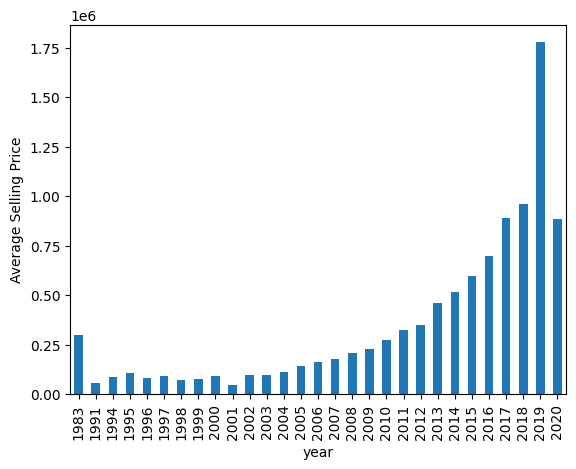

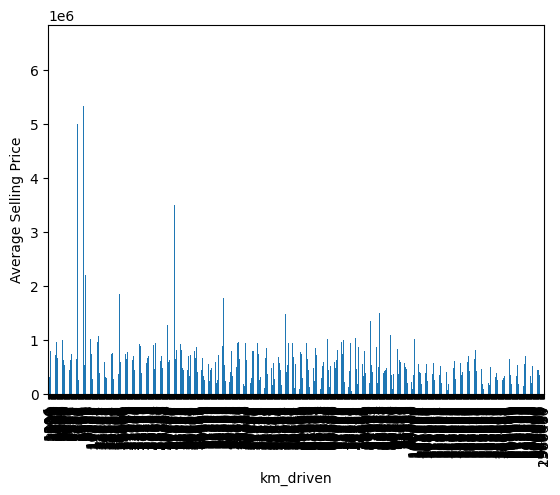

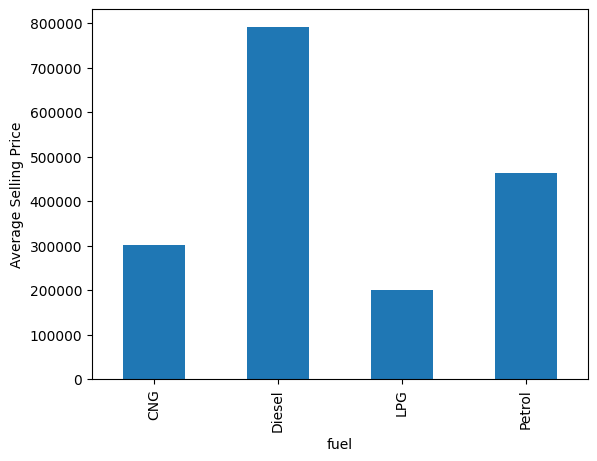

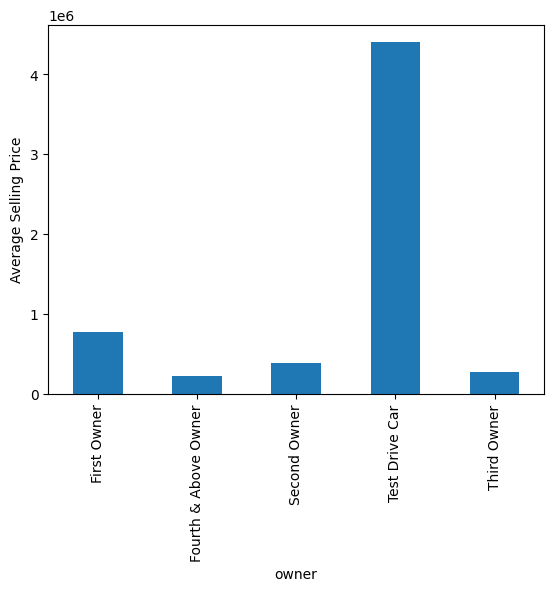

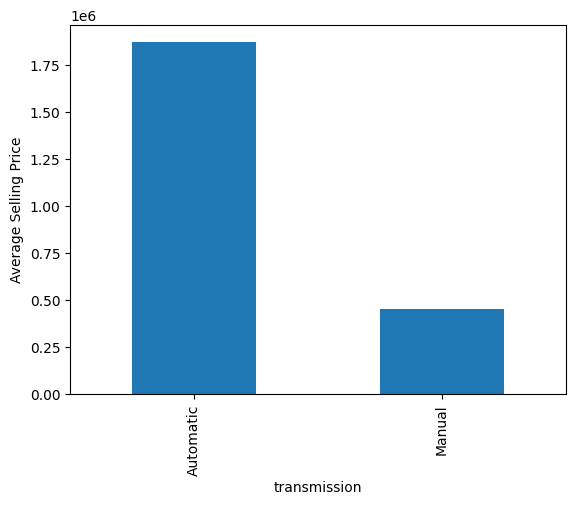

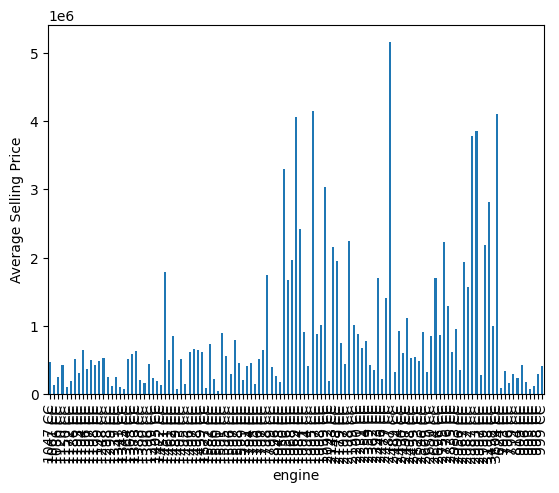

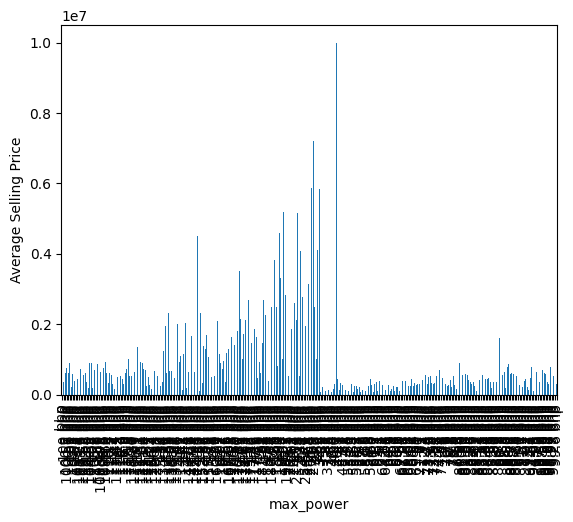

In [62]:
features = ['year', 'km_driven', 'fuel', 'owner','transmission', 'engine', 'max_power']
y = data['selling_price']

for i in features:
    plt.xlabel(i)
    data.groupby(i)['selling_price'].mean().plot(kind='bar')
    plt.ylabel('Average Selling Price')
    plt.show()

In [63]:

# Features
X = data[['year', 'km_driven', 'fuel', 'owner',
          'transmission', 'engine', 'max_power']].copy()

# Convert numeric text columns
for col in ['engine', 'max_power']:
    X[col] = pd.to_numeric(
        X[col].str.split().str[0],
        errors='coerce'
    )

# One-hot encode categorical features
X = pd.get_dummies(
    X,
    columns=['fuel', 'owner', 'transmission'],
    drop_first=True
)

y = data['selling_price']

# Train model and get feature importance
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

# Top features from importance analysis
X_small = X[['max_power', 'year', 'km_driven', 'engine']]

# Compare performance
score_all = cross_val_score(
    model, X, y, cv=5, scoring='r2'
).mean()

score_small = cross_val_score(
    model, X_small, y, cv=5, scoring='r2'
).mean()

print(f"All features R²:   {score_all:.4f}")
print(f"Top features R²:   {score_small:.4f}")

max_power                     0.737860
year                          0.198506
km_driven                     0.027072
engine                        0.026595
fuel_Diesel                   0.002634
transmission_Manual           0.002480
fuel_Petrol                   0.002327
owner_Second Owner            0.001495
owner_Test Drive Car          0.000616
owner_Third Owner             0.000265
owner_Fourth & Above Owner    0.000143
fuel_LPG                      0.000007
dtype: float64
All features R²:   0.9610
Top features R²:   0.9609
